# Telco Customer Churn - Model Training and Evaluation

This picks up where the EDA notebook left off. The plan: split the data, deal with the class
imbalance, train a few different models, run cross-validation on all of them, see how they hold
up on a held-out test set, tune the best one, and save it.

Input file: `data/telco_customer_churn_processed.csv`.


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import joblib

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost isn't installed - it'll be skipped below.")

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Loading the processed data


In [2]:
DATA_PATH = Path("data") / "telco_customer_churn_processed.csv"
if not DATA_PATH.exists():
    DATA_PATH = Path("..") / "data" / "telco_customer_churn_processed.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)

target_col = 'Churn'
print("Churn rate:", f"{df[target_col].mean():.2%}")
df.head()


Shape: (7032, 35)
Churn rate: 26.58%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_bins_13-24 months,tenure_bins_25-48 months,tenure_bins_49-72 months
0,0,0,1,0,-1.280248,0,1,-1.161694,-0.994194,0,...,False,False,False,False,False,True,False,False,False,False
1,1,0,0,0,0.064303,1,0,-0.260878,-0.173740,0,...,False,False,True,False,False,False,True,False,True,False
2,1,0,0,0,-1.239504,1,1,-0.363923,-0.959649,1,...,False,False,False,False,False,False,True,False,False,False
3,1,0,0,0,0.512486,0,0,-0.747850,-0.195248,0,...,False,False,True,False,False,False,False,False,True,False
4,0,0,0,0,-1.239504,1,1,0.196178,-0.940457,1,...,False,False,False,False,False,True,False,False,False,False


## Splitting the data

80/20 split, stratified so both sets keep roughly the same churn rate. The test set stays
untouched from here on - no resampling, no scaling adjustments, nothing. It needs to look like
real-world data.


In [3]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("\nTrain churn counts:\n", y_train.value_counts())
print("\nTest churn counts:\n", y_test.value_counts())


Train: (5625, 34) Test: (1407, 34)

Train churn counts:
 Churn
0    4130
1    1495
Name: count, dtype: int64

Test churn counts:
 Churn
0    1033
1     374
Name: count, dtype: int64


## Dealing with class imbalance

Churn sits at about 73/27, which is enough that a model trained on the raw data will lean
toward predicting "no churn" most of the time. We use SMOTE on the training set - it generates
synthetic examples of the minority class until both classes are balanced. The test set is left
exactly as it is, so the final numbers reflect what we'd actually see in production.


In [4]:
print("Before SMOTE:\n", y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:\n", pd.Series(y_train_smote).value_counts())


Before SMOTE:
 Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
 Churn
0    4130
1    4130
Name: count, dtype: int64


## Training three models

- **Logistic Regression** - simple, interpretable baseline.
- **Random Forest** - handles non-linear relationships and feature interactions, with
  `class_weight='balanced'` as an extra layer of imbalance handling on top of SMOTE.
- **XGBoost** - gradient boosting, usually one of the strongest options for tabular data. We
  set `scale_pos_weight` based on the (now balanced) training set.

All three are trained on the SMOTE-resampled training data.


In [5]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
}

if HAS_XGB:
    scale_pos_weight = (y_train_smote == 0).sum() / (y_train_smote == 1).sum()
    models['XGBoost'] = XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
    )

fitted_models = {}
for name, model in models.items():
    print("Training", name)
    model.fit(X_train_smote, y_train_smote)
    fitted_models[name] = model

print("Done.")


Training LogisticRegression


Training RandomForest


Training XGBoost


Done.


## Cross-validation on all three models

Before touching the test set, we run 5-fold stratified cross-validation on each model using the
SMOTE-resampled training data. This gives a sense of how stable each model is - not just a
single number, but a mean and a spread across folds.

For each model and each fold: train on 4/5 of the data, check ROC-AUC, F1, precision and recall
on the remaining 1/5.


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, model in models.items():
    scores = {'roc_auc': [], 'f1': [], 'precision': [], 'recall': []}

    for train_idx, val_idx in cv.split(X_train_smote, y_train_smote):
        X_tr, X_val = X_train_smote.iloc[train_idx], X_train_smote.iloc[val_idx]
        y_tr, y_val = y_train_smote.iloc[train_idx], y_train_smote.iloc[val_idx]

        fold_model = model.__class__(**model.get_params())
        fold_model.fit(X_tr, y_tr)

        pred = fold_model.predict(X_val)
        proba = fold_model.predict_proba(X_val)[:, 1]

        scores['roc_auc'].append(roc_auc_score(y_val, proba))
        scores['f1'].append(f1_score(y_val, pred))
        scores['precision'].append(precision_score(y_val, pred))
        scores['recall'].append(recall_score(y_val, pred))

    row = {'model': name}
    for metric, vals in scores.items():
        vals = np.array(vals)
        row[f'{metric}_mean'] = vals.mean()
        row[f'{metric}_std'] = vals.std()
    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df.round(4))


,model,roc_auc_mean,roc_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std
0,LogisticRegression,0.8915,0.0031,0.8107,0.0062,0.7923,0.0070,0.8300,0.0106
1,RandomForest,0.9248,0.0020,0.8492,0.0048,0.8241,0.0093,0.8760,0.0122
2,XGBoost,0.9147,0.0039,0.8401,0.0093,0.8189,0.0101,0.8625,0.0128


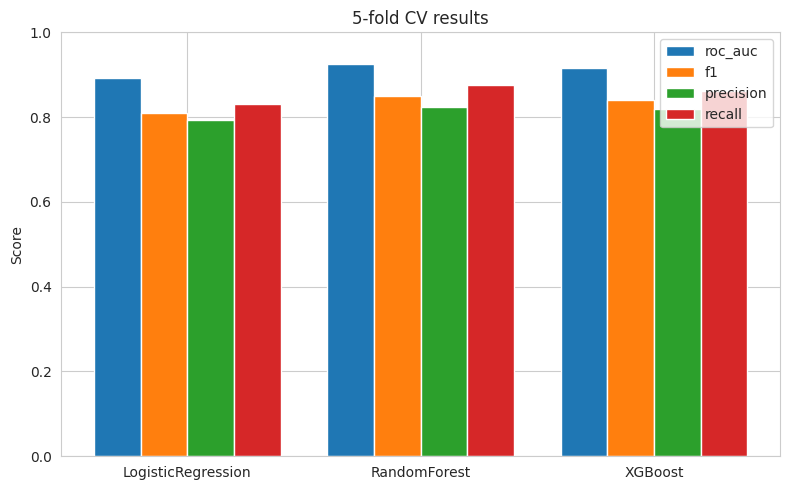

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
metrics_to_plot = ['roc_auc_mean', 'f1_mean', 'precision_mean', 'recall_mean']
x = np.arange(len(cv_results_df))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, cv_results_df[metric], width, label=metric.replace('_mean', ''))

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(cv_results_df['model'])
ax.set_ylabel('Score')
ax.set_title('5-fold CV results')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


Random Forest and XGBoost both come out ahead of Logistic Regression here, with Random Forest
slightly on top. The standard deviations are small across the board, so none of these results
look like a fluke of one particular fold split.


## Now the real test - held-out test set

Cross-validation was all on resampled data. This is the actual, untouched 73/27 test set. A few
things matter more than plain accuracy here:

- **ROC-AUC** - how well the model ranks churners above non-churners across all thresholds.
- **Recall (churn)** - of the customers who actually churned, how many did we catch? This is
  usually the number that matters most for a retention team.
- **Precision (churn)** - of the customers we flagged as likely to churn, how many actually did?
- **F1** - balances the two above.


In [8]:
results = []
roc_data = {}

for name, model in fitted_models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'model': name,
        'roc_auc': roc_auc_score(y_test, proba),
        'f1_churn': f1_score(y_test, pred),
        'precision_churn': precision_score(y_test, pred),
        'recall_churn': recall_score(y_test, pred),
    })
    roc_data[name] = roc_curve(y_test, proba)

    print(f"\n--- {name} ---")
    print(classification_report(y_test, pred, digits=4, target_names=['No Churn', 'Churn']))

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False).reset_index(drop=True)
display(results_df.round(4))



--- LogisticRegression ---
              precision    recall  f1-score   support

    No Churn     0.8709    0.7512    0.8067      1033
       Churn     0.5019    0.6925    0.5820       374

    accuracy                         0.7356      1407
   macro avg     0.6864    0.7219    0.6943      1407
weighted avg     0.7728    0.7356    0.7469      1407


--- RandomForest ---
              precision    recall  f1-score   support

    No Churn     0.8583    0.8093    0.8331      1033
       Churn     0.5450    0.6310    0.5849       374

    accuracy                         0.7619      1407
   macro avg     0.7017    0.7202    0.7090      1407
weighted avg     0.7750    0.7619    0.7671      1407




--- XGBoost ---
              precision    recall  f1-score   support

    No Churn     0.8481    0.7948    0.8206      1033
       Churn     0.5171    0.6070    0.5584       374

    accuracy                         0.7448      1407
   macro avg     0.6826    0.7009    0.6895      1407
weighted avg     0.7601    0.7448    0.7509      1407



,model,roc_auc,f1_churn,precision_churn,recall_churn
0,RandomForest,0.8155,0.5849,0.5450,0.6310
1,LogisticRegression,0.8137,0.5820,0.5019,0.6925
2,XGBoost,0.8060,0.5584,0.5171,0.6070


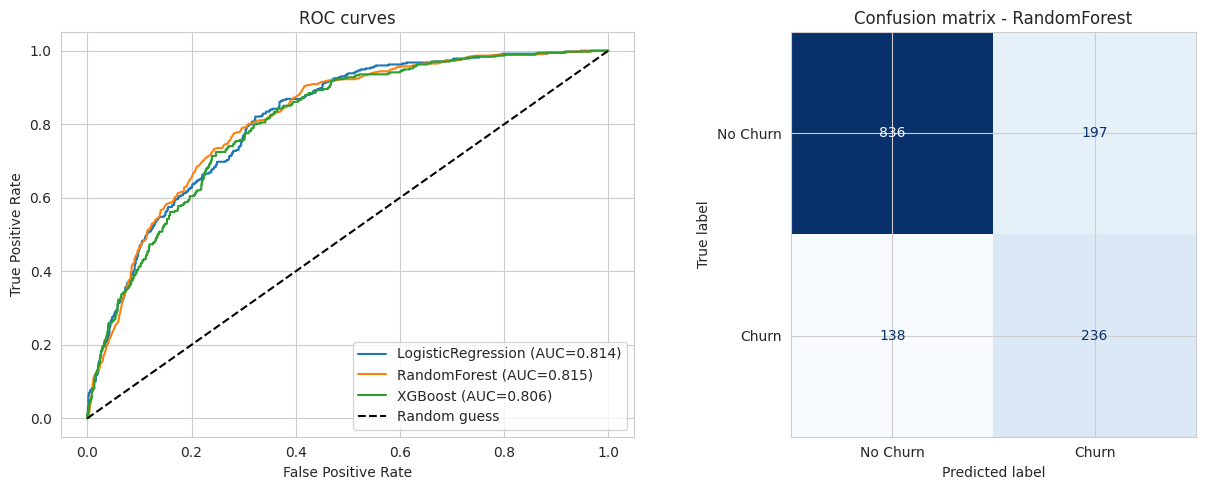

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, (fpr, tpr, _) in roc_data.items():
    auc = results_df.loc[results_df['model'] == name, 'roc_auc'].values[0]
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curves')
axes[0].legend()

best_name = results_df.iloc[0]['model']
best_model = fitted_models[best_name]
cm = confusion_matrix(y_test, best_model.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Confusion matrix - {best_name}')

plt.tight_layout()
plt.show()


## Picking a model

Mainly by ROC-AUC, with recall on the churn class as the tie-breaker since missing a churner
tends to cost more than a false alarm.


In [10]:
best_row = results_df.iloc[0]
best_name = best_row['model']
best_model = fitted_models[best_name]

print("Picked:", best_name)
print("ROC-AUC:", round(best_row['roc_auc'], 4))
print("Recall (churn):", round(best_row['recall_churn'], 4))
print("Precision (churn):", round(best_row['precision_churn'], 4))


Picked: RandomForest
ROC-AUC: 0.8155
Recall (churn): 0.631
Precision (churn): 0.545


## Tuning the winner

A randomized search over a small grid of hyperparameters, scored on ROC-AUC with 5-fold
stratified CV, run on the SMOTE-resampled training data. The grid changes depending on which
model won above.


In [11]:
if best_name == 'RandomForest':
    estimator = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    param_distributions = {
        'n_estimators': [100, 200, 300, 400],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    }
elif best_name == 'XGBoost' and HAS_XGB:
    estimator = XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE)
    param_distributions = {
        'n_estimators': [100, 200, 300, 400],
        'max_depth': [3, 5, 6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
    }
else:
    estimator = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    param_distributions = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear'],
    }

print("Tuning", best_name)
search = RandomizedSearchCV(
    estimator,
    param_distributions,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train_smote, y_train_smote)

print("Best CV ROC-AUC:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

final_model = search.best_estimator_


Tuning RandomForest


Best CV ROC-AUC: 0.9259
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


## Did tuning actually help?

Comparing the tuned model against the pre-tuning numbers on the test set.


In [12]:
pred = final_model.predict(X_test)
proba = final_model.predict_proba(X_test)[:, 1]

final_auc = roc_auc_score(y_test, proba)
final_f1 = f1_score(y_test, pred)
final_recall = recall_score(y_test, pred)
final_precision = precision_score(y_test, pred)

print(classification_report(y_test, pred, digits=4, target_names=['No Churn', 'Churn']))

comparison = pd.DataFrame({
    'metric': ['roc_auc', 'f1_churn', 'precision_churn', 'recall_churn'],
    'before_tuning': [best_row['roc_auc'], best_row['f1_churn'], best_row['precision_churn'], best_row['recall_churn']],
    'after_tuning': [final_auc, final_f1, final_precision, final_recall],
})
comparison['change'] = comparison['after_tuning'] - comparison['before_tuning']
display(comparison.round(4))


              precision    recall  f1-score   support

    No Churn     0.8610    0.8093    0.8343      1033
       Churn     0.5482    0.6390    0.5901       374

    accuracy                         0.7640      1407
   macro avg     0.7046    0.7242    0.7122      1407
weighted avg     0.7778    0.7640    0.7694      1407


,metric,before_tuning,after_tuning,change
0,roc_auc,0.8155,0.8171,0.0017
1,f1_churn,0.5849,0.5901,0.0052
2,precision_churn,0.5450,0.5482,0.0031
3,recall_churn,0.6310,0.6390,0.0080


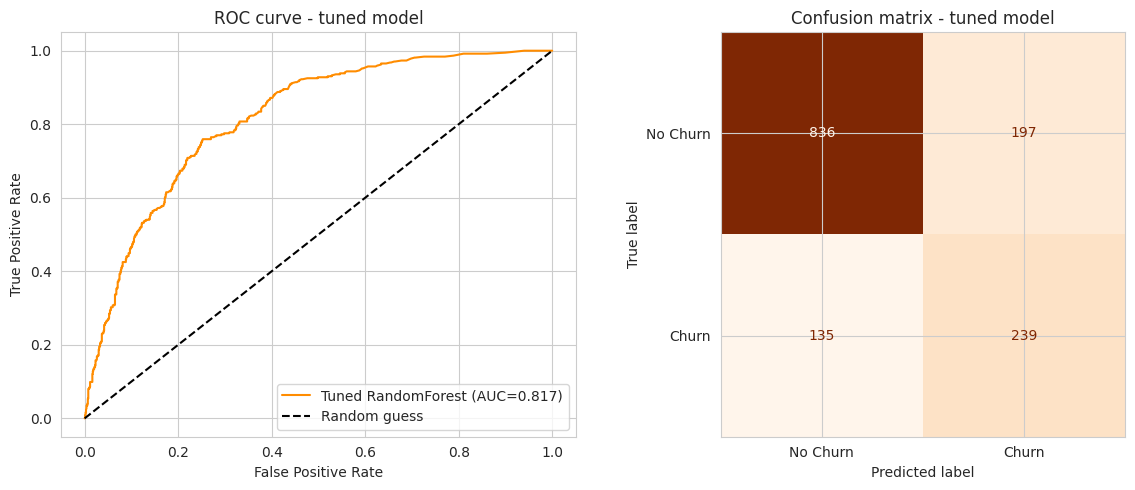

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, proba)
axes[0].plot(fpr, tpr, label=f'Tuned {best_name} (AUC={final_auc:.3f})', color='darkorange')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curve - tuned model')
axes[0].legend()

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('Confusion matrix - tuned model')

plt.tight_layout()
plt.show()


## What's driving the predictions

Worth a look at which features the model leans on most - useful both for sanity-checking the
model and for giving the retention team something concrete to act on.


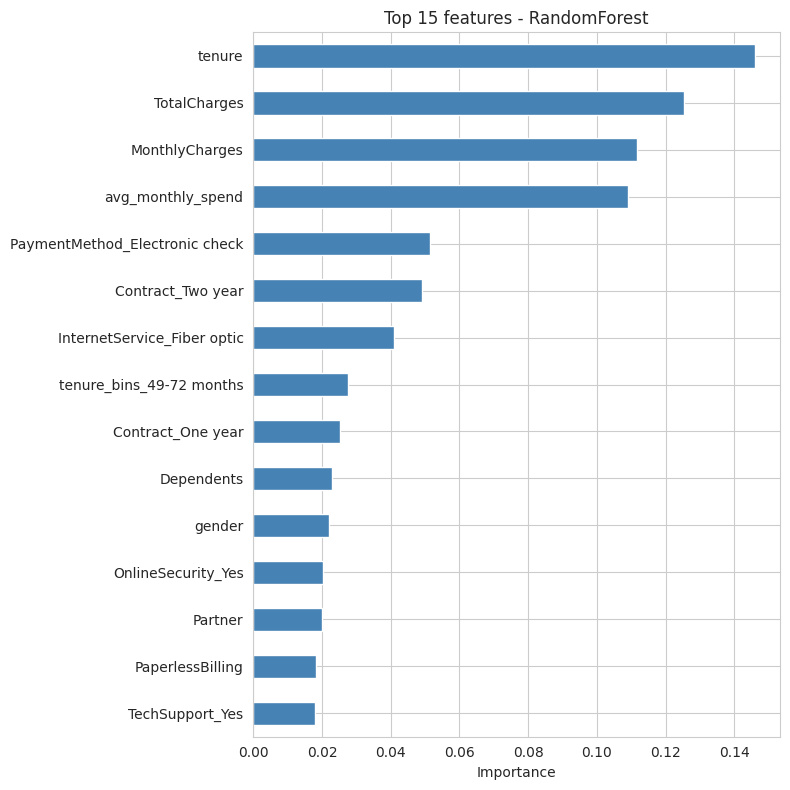

tenure                            0.145954
TotalCharges                      0.125468
MonthlyCharges                    0.111698
avg_monthly_spend                 0.109041
PaymentMethod_Electronic check    0.051533
Contract_Two year                 0.049127
InternetService_Fiber optic       0.040940
tenure_bins_49-72 months          0.027712
Contract_One year                 0.025285
Dependents                        0.022960
gender                            0.021937
OnlineSecurity_Yes                0.020301
Partner                           0.020149
PaperlessBilling                  0.018265
TechSupport_Yes                   0.018010
dtype: float64

In [14]:
if hasattr(final_model, 'feature_importances_'):
    importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=(8, 8))
    importances.head(15).sort_values().plot(kind='barh', color='steelblue')
    plt.title(f'Top 15 features - {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    display(importances.head(15))
elif hasattr(final_model, 'coef_'):
    coefs = pd.Series(final_model.coef_[0], index=X.columns).sort_values()

    plt.figure(figsize=(8, 8))
    pd.concat([coefs.head(8), coefs.tail(8)]).sort_values().plot(kind='barh', color='steelblue')
    plt.title('Top coefficients - Logistic Regression')
    plt.xlabel('Coefficient (log-odds)')
    plt.tight_layout()
    plt.show()

    display(coefs)


## Saving the model


In [15]:
model_dir = Path("models")
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / "best_model.pkl"

joblib.dump(final_model, model_path)

print("Saved to", model_path.resolve())
print("Model:", best_name)
print("Best params:", search.best_params_)
print(f"Test ROC-AUC: {final_auc:.4f} | Test recall (churn): {final_recall:.4f}")


Saved to /home/claude/models/best_model.pkl
Model: RandomForest
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Test ROC-AUC: 0.8171 | Test recall (churn): 0.6390


## Wrapping up

- SMOTE on the training set, model trained and validated on it, tested on the original 73/27
  split.
- All three models cross-validated with 5 folds; Random Forest and XGBoost both clearly beat
  Logistic Regression, with Random Forest slightly ahead.
- Tuned with `RandomizedSearchCV`, saved to `models/best_model.pkl`.

Things worth trying next:

- The default 0.5 cutoff for "churn vs not" isn't necessarily the right one. Worth tuning it
  against an actual cost - what does it cost to miss a churner versus offering a retention deal
  to someone who wasn't going to leave anyway?
- If the predicted probabilities themselves matter (for ranking customers by risk, say), running
  them through `CalibratedClassifierCV` would help.
- A few of the one-hot columns overlap (e.g. the various `*_No internet service` columns all
  say the same thing as `InternetService_No`) - could simplify the feature set a bit.
- `SMOTETomek` or `SMOTEENN` might clean up the synthetic samples near the class boundary better
  than plain SMOTE.
- The feature importance list is a good starting point for a conversation with the retention
  team about what to actually do about churn.
